# Learning a function f
Machine learning algorithms aim to **learn a target function $f$** that best maps input variables ($X$) to an output variable ($Y$):


$$ Y = f(X) $$

What function $f$ *exactly* is or *how* it looks, is not known. And exactly that (what the function $f$ has to be) is the part that Machine Learning tries to learn from the data.


## Making predictions

The main goal of machine learning is to learn the underlying function in order to **make predictions** of $Y$ for new $X$ (unseen data). When we *train* or *learn* a machine learning model we are *estimating* the target function (the target function is the best mapping from $Y$ given $X$ from the data that is available). Usually a lot of time is spent trying to improve this estimate of the unknown target function in order to improve performance of the predictions made by the model. 

# vectorisation

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = [12, 8]

## dummy data
Let us make some dummy data $X$. This is a matrix that contains $n$ observations, each observations having $k$ features, thus forming an $n \times k$ matrix.

In [3]:
"""   
np.random.seed()    → used to ensure that the same random numbers are generated every time the code is run, making the results reproducible
np.random.randint() → returns random integers, where 
                      low  = lowest integers                                                             = 10
                      size = the output shape of tuple (n, k) generating in n * k samples, thus 1000 * 3 = 3000
"""

np.random.seed(42)
n = 1000
k = 3
X = np.random.randint(10, size=(n, k))

print(X)

[[6 3 7]
 [4 6 9]
 [2 6 7]
 ...
 [2 0 6]
 [9 4 4]
 [0 8 6]]


In this example, the first observation consists of three features. The first feature has a value of 6, the second of 3, the third of 7. To make predicication, we will want to learn what weight we should assign to every feature. Not every feature will be as important in predicting an outcome. This will depend on what we want to predict.

However, at the beginning of each learning algorithm we will randomize the weights.

In [4]:
"""
np.random.rand()    → creates an array of given shape (k, 1) and populates it with random samples between 0 - 1
W                   → results in (3,1), since k = 3 
"""

np.random.seed(42)
W = np.random.rand(k, 1)
W

array([[0.37454012],
       [0.95071431],
       [0.73199394]])

The goal will be to learn the proper weights for our type of prediction.

E.g. If the features are length, weight and body temperature, the first two features will be roughly equally important in predicting the size of someones clothes, while the third will be of no importance. 

The final weights for this case might look something like $[0.9, 0.8, 0.01]$

However, for predicting shoe size, the first feature will be more important than the last one. We might get something like $[0.9, 0.3, 0.01]$. 

For predicting infections, the last feature will be the most imporant, e.g. $[0.01, 0.1, 0.9]$.



In [ ]:
"""   
Summarized: features and their weights differ per case
"""

## Forloop
If we want to make a prediction, often denoted as $\hat{y}$ (y-hat), a very general way to do so is to multiply every feature with a weight:

$$\begin{equation}
\hat{y} = w_1 x_1 + \dots + w_n x_n
\end{equation}
$$

This approach is a basic element in many machine learning algorithms. We might add some extra tricks, like Baysian Statistics, SVM's or stacking Neural Network layers upon eachother.

A naive way to calculate this, would be while using a forloop. Making an empty matrix of zeros with the right shape is much faster then appending an outcome to a list.

In [5]:
"""
X                   → dummy dataof 1000 rows x 3 columns (observations x features)
W                   → previous generated weights (random at this point)
result              → array of zeros shaped (1000 x 1)
enumerate()         → loops over an iterable and returns both the index and the element (the index is represented by i and j in the for loops)
return(result)      → returns array 'result' where zeros have been replaced with an aggregation of X' features * weights
                      EXAMPLE:
                      X[0]      = [6 3 7]
                      feature   = X[0]' individual elements
                      W         = [[0.37454012]  [0.95071431]  [0.73199394]]
                      j         = index of W
                      yhat      = 0
                      
                      yhat      = yhat + W[j] * feature
                                = 0          + 0.37454012 * 6    = 2.24724072
                                = 2.24724072 + 0.95071431 * 3    = 5.09938365
                                = 5.09938365 + 0.73199394 * 7    = 10.22334123
                      
                      result[0] = 10.22334123
"""

def for_loop(X, W):
    result = np.zeros((X.shape[0],W.shape[1]))
    # for every observation
    for i, observation in enumerate(X):
        yhat = 0
        # we want to multiply every feature with a weight
        for j, feature in enumerate(observation):
            # and make a summation of every weigth * feature
            yhat += W[j] * feature
        result[i, 0] = yhat
    return(result)

We can time a piece of code like this. This will run the line enough times to obtain a good average.

In [6]:
"""
Really handy to use in the future :)
"""

looptime = %timeit -o for_loop(X, W)

/tmp/ipykernel_134969/4259827834.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result[i, 0] = yhat


10.9 ms ± 21.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Now, let's scale that up and do a gridsearch:

In [ ]:
"""
range(start,stop)   → returns a sequence of numbers between start and stop (excl. stop) which increases by 1 by default (this can be adapted by adding step = n), where
                      start = 2
                      stop  = 5
heatmap_for         → array of zeros with shape (3 x 2)
**                  → exponential. Example: 3 ** 3 = 27
loop example [0]    → for i, n in enumerate([10**i for i in nrange]):
                      i = index = 0
                      n = element
                        = 10**i for i in nrange → nrange[i] = nrange[0] = 2
                        = 10**2 = 100

                        for j, k in enumerate([10**i for i in krange]):         → imagine 'i' is replaced by 'j'. It returns the same result, since it's looping through krange
                        j = index = 0
                        k = element
                          = 10**i for i in krange → krange[i] = krange[0] = 1
                          = 10**1 = 10

                          X = np.random.randint(10, size=(n, k))                → random integers, where high = 10 and returns an array of shape (100 x 10)
                          W = np.random.rand(k, 1)                              → array containing random samples of a uniform distribution (between 0-1) of shape (10 x 1)
                          looptime = %timeit -o for_loop(X, W)                  → times the piece of code with (newly) generated X and W parameters
                          heatmap_for[i, j] = looptime.average                  → looptime average is added to an array

observation         → why is there a logger here and not in the solutions? I actually think a accidentally deleted it in the solutions file                      
"""



from loguru import logger
np.random.seed(42)
nrange = range(2,5)
krange = range(1,3)
heatmap_for = np.zeros((len(nrange),len(krange)))

for i, n in enumerate([10**i for i in nrange]):
    for j, k in enumerate([10**i for i in krange]):
        """ print("i = {}, n = {}, j = {}, k = {}".format(i, n, j, k)) """
        X = np.random.randint(10, size=(n, k))
        W = np.random.rand(k, 1)
        looptime = %timeit -o for_loop(X, W)
        heatmap_for[i, j] = looptime.average
        logger.info(f"n={n}, k={k}, avg={looptime.average:.6f}")


/tmp/ipykernel_134969/4259827834.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  result[i, 0] = yhat
2026-04-11 11:50:46.846 | INFO     | __main__:<module>:42 - n=100, k=10, avg=0.003164


3.16 ms ± 8.65 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


2026-04-11 11:50:49.231 | INFO     | __main__:<module>:42 - n=100, k=100, avg=0.029387


29.4 ms ± 33.5 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


2026-04-11 11:50:51.793 | INFO     | __main__:<module>:42 - n=1000, k=10, avg=0.031565


...

294 ms ± 655 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


2026-04-11 11:50:57.984 | INFO     | __main__:<module>:42 - n=10000, k=10, avg=0.501802


502 ms ± 200 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


2026-04-11 11:51:27.740 | INFO     | __main__:<module>:42 - n=10000, k=100, avg=3.623560


3.62 s ± 818 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


<Axes: >

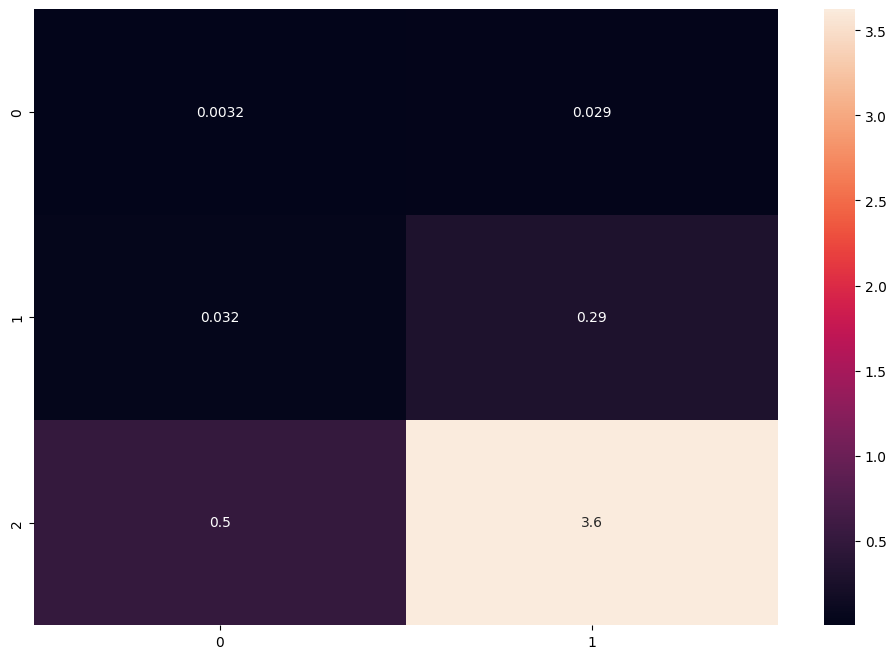

In [8]:
"""
generates a heatmap, where
data  = heatmap_for (an array of average looptimes)
annot = writes the data value of heatmap_for in each cell 
"""

sns.heatmap(heatmap_for, annot=heatmap_for)

On my laptop, I get results that:
- scale linear: multiplying the amount of observations or features by 10, will add about a factor of 10 to the time.
- ranges between 0.0029 sec (for 100 observations with one feature) and 2.7 sec (for 10.000 observations and 100 features) on average.

## vectorisation
Now, we will vectorize this calculation.

Note that, for matrix multiplication to work, we will need the dimensions of the two matrices to match. If our first matrix $X$ has dimensions $(n, k)$ and our second matrix $W$ has dimensions $(k, m)$, we are able to do $X \dot W$ because the dimension $k$ is equal.

So, trying to do a matrix multiplication with dimensions (10, 3) and (3, 1) will work, but (10,3) and (4,1) will fail because $3\neq 4$.

Also, trying to multiply (3,1) and (10, 3) will fail because $1 \neq 10$. This means the order is important. This is different from normal multiplication, where $2 \times 3$ and $3 \times 2$ both equal to 6.

Let's say our data has $n=2$ cases ($a$ and $b$), where we observe $k=2$ features for every case. We now need two weights $w_1$ and $w_2$, one for every feature. A matrix multiplication would do exactly what we did with the forloop:

$$
\begin{bmatrix}
a_{1} & a_2 \\
b_{1} & b_{2}
\end{bmatrix}
\begin{bmatrix}
w_1 \\
w_2
\end{bmatrix}
=
\begin{bmatrix}
a_1*w_1 + a_2*w_2\\
b_1*w_1 + b_2*w_2
\end{bmatrix}
$$

If we implement the same formula, we see that everything gets much more compact.

In [ ]:
"""   
Summarized: the amount of weights should be equal to the amount of features, so each feature can be multiplied by an individual weight
"""

In [9]:
"""  
np.dot(X,W)         → dot product of two arrays
"""

def vectorisation(X, W):
    return np.dot(X, W)

Lets run the same experiment, but just swap the forloop.

In [10]:
"""   
Same code as four blocks before, but the looptime investigates function vectorisation() instead of for_loop()
"""

np.random.seed(42)
nrange = range(2,5)
krange = range(1,3)
heatmap_vec = np.zeros((len(nrange),len(krange)))

for i, n in enumerate([10**i for i in nrange]):
    for j, k in enumerate([10**i for i in krange]):
        X = np.random.randint(10, size=(n, k))
        W = np.random.rand(k, 1)
        looptime = %timeit -o vectorisation(X, W)
        heatmap_vec[i, j] = looptime.average
        logger.info(f"n={n}, k={k}, avg={looptime.average:.6f}")

2026-04-11 11:52:12.382 | INFO     | __main__:<module>:16 - n=100, k=10, avg=0.000002


2.24 μs ± 4.19 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


2026-04-11 11:52:17.462 | INFO     | __main__:<module>:16 - n=100, k=100, avg=0.000006


6.26 μs ± 7.01 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


2026-04-11 11:52:24.472 | INFO     | __main__:<module>:16 - n=1000, k=10, avg=0.000009


...

52.3 μs ± 146 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


2026-04-11 11:52:34.985 | INFO     | __main__:<module>:16 - n=10000, k=10, avg=0.000077


77.2 μs ± 70.6 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


2026-04-11 11:52:36.952 | INFO     | __main__:<module>:16 - n=10000, k=100, avg=0.002393


2.39 ms ± 21.2 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


<Axes: >

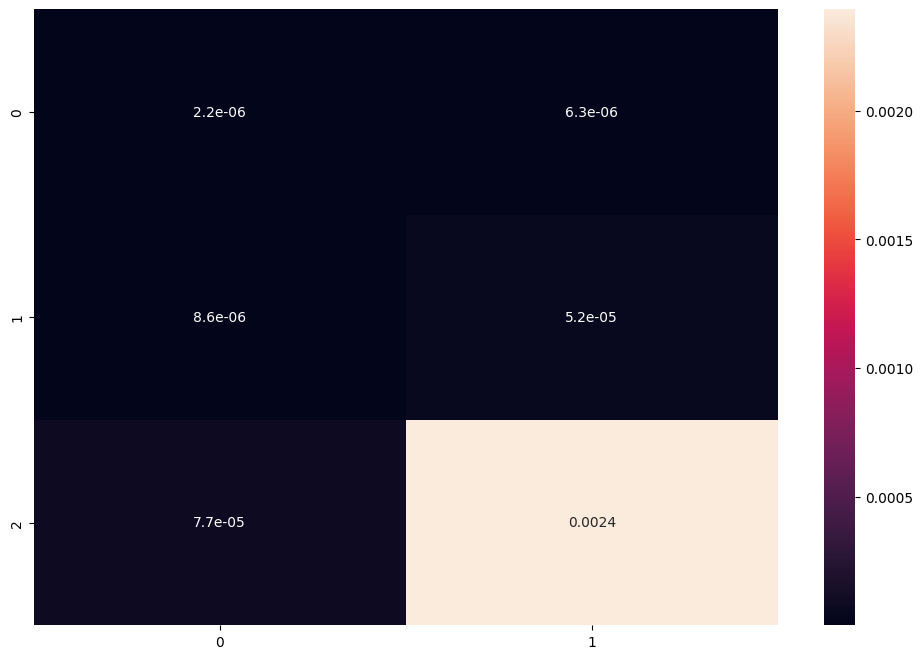

In [11]:
sns.heatmap(heatmap_vec, annot=heatmap_vec)

I think this is impressive. Not only is the linear scaling gone, but this is really an amazing amount faster!

In [ ]:
"""   
Question: Is it a good thing that linear scaling is gone? Yes, since the results generate much faster
"""

<Axes: >

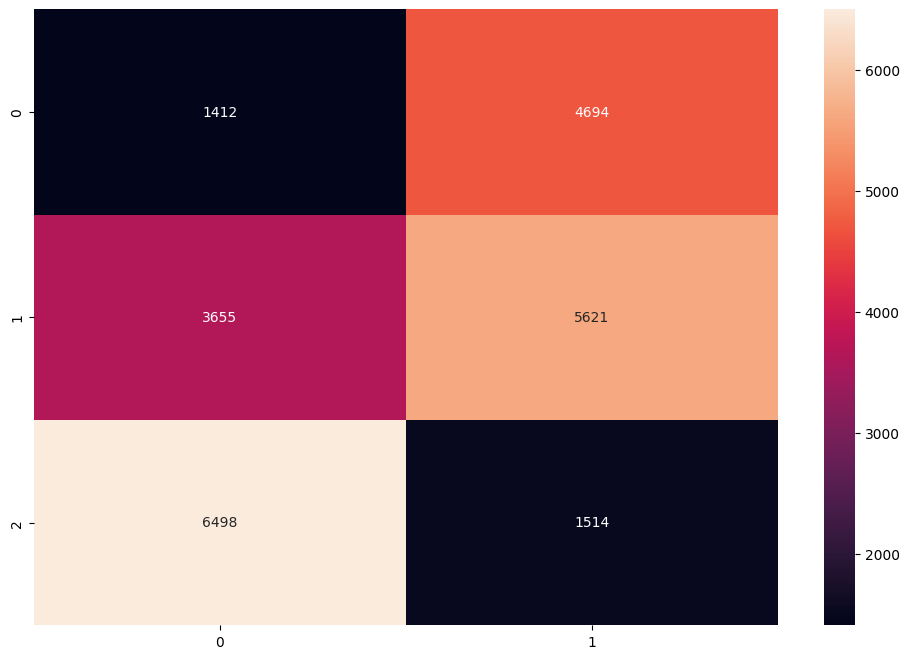

In [12]:
"""   
Array of the for_loop is divided by array of the vectors, showing the difference in looptime
"""

speedup = heatmap_for / heatmap_vec
sns.heatmap(speedup, annot=speedup,fmt='.0f')

Yes, that is right. For the very small case (100 observations, 1 feature) the speedup is about 1400 times.

For larger scales, if you are using newer versions of python (eg 3.11) the speedup isnt as impressive with older versions (used to be a factor 3000, even 4000).
However, being 300 times slower than someone else is still not something to be proud of.

I hope you can imagine how extremely useful this can be. Even when python has gotten 10x faster in some cases, a factor 300x can still make the difference between useful and useless.

The same can be done with other functions, like calculating a sine:

In [13]:
"""   
X = np.random.rand(100) → array containing random samples of a uniform distribution (between 0-1) of shape (100 x 1)
np.sin(x)               → calculates the trigonometric sine for x in X
"""

X = np.random.rand(100)
%timeit for x in X: np.sin(x)

96.4 μs ± 641 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


But, instead of the forloop, we can do that in way that is both simpler and faster:

In [14]:
"""  
Simpler and faster method than above. sin the whole array and time that at once instead of timing all individual calculations
"""

%timeit np.sin(X)

1.51 μs ± 190 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


Which gives us the exact same results.

In addition to this, we don't have to worry too much about adding extra dimensions. Numpy simply scales things:

In [15]:
"""   
Examples about numpy scaling things
"""

X = np.random.rand(100,100)
x1 = np.log(X)
x2 = np.exp(X)
X = np.random.rand(10, 10, 10)
x3 = np.sin(X)

A variation on matrix multiplication is element wise multiplication, also known as the Hadamard product. Compare the two examples below:

In [16]:
"""   
Hadamard product    → 70  = 1 x 10 + 2 x 30
                      100 = 1 x 20 + 2 x 40
                      150 = 3 x 10 + 4 x 30
                      220 = 3 x 20 + 4 x 40
"""

A = np.array([[1,2],
              [3,4]])

B = np.array([[10,20],
              [30,40]])
np.dot(A, B)

array([[ 70, 100],
       [150, 220]])

Here, we calculate $(1 \times 10) + (2 \times 30)$ for the first entry, which is 70.

However, what if we wanted to multiply every element with the same element in the other matrix (so, every element at position $(i,j)$ in $A$ is multiplied with every $(i,j)$ element in $B$).

In [17]:
np.multiply(A, B)

array([[ 10,  40],
       [ 90, 160]])

This equals to:

In [18]:
A * B

array([[ 10,  40],
       [ 90, 160]])

# Broadcasting

Broadcasting referes to how numpy handles arrays with different shapes. In general, the smaller array is "broadcast" across the larger array to get compatible shapes. Multiplying 1-dimensional array of the same length performs a element-wise multiplication:

In [19]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([1.0, 2.0, 3.0])
a * b

array([1., 4., 9.])

However, if the dimensions don't match, we get an error:

In [20]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([1.0, 2.0, 3.0, 4.0])
try:
     a * b
except Exception as e:
    print('Error:', e)

Error: operands could not be broadcast together with shapes (3,) (4,) 


But this constraint is relaxed when the dimensions meet certain constraints:

In [21]:
a = np.array([1.0, 2.0, 3.0])
b = 2.0
a * b

array([2., 4., 6.])

Which is equivalent to

In [22]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([2.0, 2.0, 2.0])
a * b

array([2., 4., 6.])

But just shorter. In the first case, we can think of `b` being stretched to an array of the same shape as `a`.

In general, two dimensions are compatible when:
1. they are equal
2. one of them is 1

In addition to this, array's do not need to have the same number of dimensions. Eg an image with dimensions of `256x256` pixels can have three colors. This results in a `256x256x3` shape matrix. If we want to scale each color, we can use a 1-dimensional array with 3 values.

In [23]:
image = np.random.rand(256, 256, 3)
scale = np.array([2, 3, 6])
output = image * scale
output.shape

(256, 256, 3)

In [24]:
"""   
I think I understand the theory     → if the most inner dimension matches the length of a 1D array, it is scalable and the resulting shape will match the original array
But I don't understand the results 
"""

image = np.random.rand(256, 256, 3)
print("scale:\n{0}\n\nimage[{1}][{1}]:\n{2}\n\noutput[{1}][{1}]:\n{3}\n\n".format(scale, 0, image[0][0], output[0][0]))


"""   
Let's see if this generates the expected results 
            → it does. 
Soooo maybe the same positions don't correspond to the fitting outcome after multiplication? 
            → no, I probably made a mistake while coding, since both tests underneath match the results I expected
"""
image2  = np.array([0.96201334, 0.23843939, 0.77845596])
scale2  = np.array([2, 3, 6])
output2 = image2 * scale2
print("TEST #1:\n{}".format(output2))


"""   
Another test with smaller dimensions → matches my expectations!
"""
image3  = np.random.rand(2, 2, 3)
scale3  = np.array([1, 2, 3])
output3 = image3 * scale3
print("\n\nTEST #2:\nimage3:\n{}\n\nscale3:\n{}\n\noutput3:\n{}\n\n".format(image3, scale3, output3))

scale:
[2 3 6]

image[0][0]:
[0.80580517 0.56755529 0.36953509]

output[0][0]:
[1.76253304 2.04343061 0.89356465]


TEST #1:
[1.92402668 0.71531817 4.67073576]


TEST #2:
image3:
[[[0.91147314 0.92102587 0.71693462]
  [0.52907893 0.12601336 0.94692672]]

 [[0.88251431 0.83813183 0.12235726]
  [0.0020535  0.26098218 0.7809202 ]]]

scale3:
[1 2 3]

output3:
[[[9.11473139e-01 1.84205173e+00 2.15080385e+00]
  [5.29078933e-01 2.52026726e-01 2.84078015e+00]]

 [[8.82514307e-01 1.67626367e+00 3.67071767e-01]
  [2.05350053e-03 5.21964368e-01 2.34276059e+00]]]




This "broadcasting" works along multiple dimensions

In [25]:
A = np.random.rand(15, 3, 5)
B = np.random.rand(15, 1, 5)
C = A * B
C.shape

(15, 3, 5)

Or more complex:

In [26]:
"""  
I wonder how this is decided..
"""

A = np.random.rand(8, 1, 6, 1)
B = np.random.rand(7, 1, 5)
C = A*B
C.shape

(8, 7, 6, 5)

Can you figure out what happened here?

# Exercise
You receive data from 1000 patients. For every patient, there are 8 features.

In [51]:
np.random.seed(42)
n = 1000
k = 8
X = np.random.rand(n, k)
X.shape

(1000, 8)

You want to build a simple linear model, and start by implementing the formula $f(x) = \sum_{i=1}^n w_i * x_i $

First, you initialize random weights. If you want to use matrix multiplication, what is the shape you need for the weights?

In [40]:
"""  
If I want to implement matrix multiplication, then the amount of weights need to be equal to the amount of features of X
W = (k, x), where x does not necessarily matter, but I can start with 1 to keep it simple 

Woops, aforementioned concerns vectorisation.

In order to implement matrix multiplication, the amount of dimensions need to match OR a 1D array of the same length will suffice
W = (x, k), where x can be X.shape[0] or 1 → let's go for 1 to keep things simple
"""

W = np.random.rand(1, k)
W.shape

(1, 8)

If you multiply $X$ with $W$, what do you expect the shape of the outcome to be? In the outcome, what is the meaning of every row? And every column? Implement the forumula by using `np.dot`. Did you get the dimensions right?

In [ ]:
"""   
I expect the shape of the outcome to be X * W = (1000, 8) x (1, 8) = (1000, 8)
"""

outcome = X * W
print(outcome.shape)

(1000, 8)


Now, assume that instead of predicting one outcome, you want to predict two different things (e.g., both the expected duration of a stay, and the chance of complications during the stay). Every patient still has 8 features, but the outcome should be two numbers, instead of one.

How do you need to change the shape of $W$?

What is the expected shape if you apply matrix multiplication between $X$ and $W$? What would happen if you multiply $W$ and $X$?

Create $W$ and implement the new calculation. How does this differ from the calculation with just one outcome?

In [ ]:
""" ITERATION #1
1.  How do you change the shape of W?
        Based on the given context, X remains the same: a 2D array with shape (1000, 8)
        W needs to be adapted to generate 2 results instead of 1. This sounds like W needs to contain two sets of weights 
        → (2, 1, 8)? Where (1,8) corresponds with the shape of X, but generates different results for 2 predictions
          → I don't expect this to work at all (except if another dimension of 1 is added to X, but imo that does not seem to be the intention)

2.  What is the expected shape if you apply matrix multiplication between X and W? What would happen if you multiply W and X?
        If the aforementioned shape works, I expect the resulting shape to be (2, 1000, 8). The other way around will result in the same I think

3.  How does this differ from the calculation with just one outcome?
        It differs since you end up with two outcomes.. ?
"""

In [ ]:
"""   
It works! :D

1.  ✔
2.  ✔
3.  ✔, but is this the desired answer?
"""

W2 = np.random.rand(2, 1, k)

try:
     outcome2 = np.multiply(X, W2)
     outcome3 = np.multiply(W2, X)
     print("outcome2: {}\noutcome3: {}".format(outcome2.shape, outcome3.shape))
except Exception as e:
    print('Error:', e)

outcome2: (2, 1000, 8)
outcome3: (2, 1000, 8)


In [ ]:
""" ITERATION #2
→ I checked the first answer and they do perform vectorization instead of matrix multiplication  :/
→ I think I confused matrix multiplication with broadcasting when broadcasting concerns *array* multiplication


-   If you want to use matrix multiplication, what is the shape you need for the weights?
        If I want to implement matrix multiplication, then the amount of weights need to be equal to the amount of features of X
        W = (k, x), where x does not necessarily matter, but I can start with 1 to keep it simple 

-   If you multiply X with W, what do you expect the shape of the outcome to be? 
    In the outcome, what is the meaning of every row? And every column? 
    Implement the forumula by using `np.dot`. Did you get the dimensions right?
        X = (1000, 8)
        W = (8, 1)
        np.dot is element multiplication (features are elements), so I expect the result to be (1000, 1)

        In the outcome, 1000 are the observations and 1 are the features, which are multiplied by weights and summed into a single value


1.  How do you change the shape of W?
        Instead of 1 column, change the shape so that W has 2 columns
        Thus W has shape (k, 2)

2.  What is the expected shape if you apply matrix multiplication between X and W? What would happen if you multiply W and X?
        I expect the resulting shape to be (1000, 2)

        If we try to multiply W and X, then I expect the result to be an error since W's features do not match X's observations

3.  How does this differ from the calculation with just one outcome?
        It has two outcomes instead of one..?
"""

In [53]:
"""   
ITERATION #2
"""
W = np.random.rand(k, 1)
print("shape of k: {}".format(W.shape))
outcome = np.dot(X, W)
print("outcome: {}".format(outcome.shape))


W2 = np.random.rand(k, 2)
try:
    outcome2 = np.dot(X, W2)
    print("\noutcome2: {}".format(outcome2.shape))
except Exception as e:
    print("\nError: {}".format(e))


try:
    outcome3 = np.dot(W2, X)
    print("\noutcome3: {}".format(outcome3.shape))
except Exception as e:
    print("\nError: {}".format(e))


shape of k: (8, 1)
outcome: (1000, 1)

outcome2: (1000, 2)

Error: shapes (8,2) and (1000,8) not aligned: 2 (dim 1) != 1000 (dim 0)


In [ ]:
"""
Note to self: np.dot resulting columns = the smallest amount of columns of the matrices that are multiplied (since the columns are summed at the end)
              → No, the overlapping number is 'removed'
                Examples:   (1, 2) x (2, 3) → (1, 3)
                            (2, 3) x (3, 4) → (2, 4)
                            (5, 2) x (2, 1) → (5, 1)

Checking the solutions:
-   ✔
-   ✔
1.  ✔
2.  no answer available
3.  no answer available                            
"""


X x Y: results in shape (1, 3)
X x A: results in shape (1, 1)
Y x Z: results in shape (2, 4)
Error, C x Y results in: shapes (4,3) and (2,3) not aligned: 3 (dim 1) != 2 (dim 0)
Z x C: results in shape (3, 3)
